In [1]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy
import numpy as np
from collections import defaultdict
import sys

In [2]:
def traverse_folder(folder_data, folder_path, graph, parent=None):
    """Traverse folder structure recursively"""
    pristine_count = 0
    lost_count = 0
    replica_count = 0
    total_files = 0

    graph.add_node(folder_path, node_type='folder')

    if parent:
        graph.add_edge(parent, folder_path)

    if 'files' in folder_data:
        for filename, file_info in folder_data['files'].items():
            total_files += 1
            status = file_info.get('status', 'unknown')
            replicas = file_info.get('replicas', [])

            file_path = f"{folder_path}/{filename}"
            graph.add_node(file_path, node_type='file')
            graph.add_edge(folder_path, file_path)

            if status == 'pristine':
                pristine_count += 1
                graph.nodes[file_path]['file_status'] = 'pristine'
            elif status == 'lost':
                if len(replicas) > 0:
                    replica_count += 1
                    graph.nodes[file_path]['file_status'] = 'replica'
                else:
                    lost_count += 1
                    graph.nodes[file_path]['file_status'] = 'lost'

    if 'folders' in folder_data:
        for subfolder_name, subfolder_data in folder_data['folders'].items():
            subfolder_path = f"{folder_path}/{subfolder_name}"
            sub_pristine, sub_lost, sub_replica, sub_total = traverse_folder(
                subfolder_data, subfolder_path, graph, folder_path
            )
            pristine_count += sub_pristine
            lost_count += sub_lost
            replica_count += sub_replica
            total_files += sub_total

    graph.nodes[folder_path]['pristine_count'] = pristine_count
    graph.nodes[folder_path]['lost_count'] = lost_count
    graph.nodes[folder_path]['replica_count'] = replica_count
    graph.nodes[folder_path]['total_files'] = total_files

    return pristine_count, lost_count, replica_count, total_files

def build_hierarchy(G):
    """Build parent-child mapping"""
    children = defaultdict(list)
    parent = {}

    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        node_type = G.nodes[node].get('node_type')

        if node_type == 'folder':
            for neighbor in neighbors:
                neighbor_type = G.nodes[neighbor].get('node_type')
                if neighbor_type in ['file', 'folder']:
                    if neighbor.startswith(node + '/'):
                        children[node].append(neighbor)
                        parent[neighbor] = node

    return children, parent

In [24]:
json_file = "wannacry-60-sss_ransomware-1-report.json"
with open(json_file, 'r') as f:
        data = json.load(f)

G = nx.Graph()
root_path = data['root']

# Add root node
G.add_node(root_path, node_type='folder')
total_pristine = 0
total_lost = 0
total_replica = 0
total_files = 0

if 'files' in data['files']:
        for filename, file_info in data['files'].items():
            total_files += 1
            status = file_info.get('status', 'unknown')
            replicas = file_info.get('replicas', [])

            file_path = f"{root_path}/{filename}"
            G.add_node(file_path, node_type='file')
            G.add_edge(root_path, file_path)

            if status == 'pristine':
                pristine_count += 1
                G.nodes[file_path]['file_status'] = 'pristine'
            elif status == 'lost':
                if len(replicas) > 0:
                    replica_count += 1
                    G.nodes[file_path]['file_status'] = 'replica'
                else:
                    lost_count += 1
                    G.nodes[file_path]['file_status'] = 'lost'

if 'folders' in data:
    for folder_name, folder_data in data['folders'].items():
        folder_path = f"{root_path}/{folder_name}"
        p, l, r, t = traverse_folder(folder_data, folder_path, G, root_path)
        total_pristine += p
        total_lost += l
        total_replica += r
        total_files += t

G.nodes[root_path]['pristine_count'] = total_pristine
G.nodes[root_path]['lost_count'] = total_lost
G.nodes[root_path]['replica_count'] = total_replica
G.nodes[root_path]['total_files'] = total_files

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Root: {root_path}")

Graph: 253 nodes, 252 edges
Root: C:/users/IEuser


pristine_files: ['C:/users/IEuser/Desktop/4465CDCE.DUM', 'C:/users/IEuser/Desktop/4C7C1D2F.DUM', 'C:/users/IEuser/Desktop/0A8AE703.DUM', 'C:/users/IEuser/Desktop/desktop.ini', 'C:/users/IEuser/Desktop/eula.lnk', 'C:/users/IEuser/Desktop/EAB16DBE.DUM', 'C:/users/IEuser/Desktop/9EF78656.DUM', 'C:/users/IEuser/Desktop/OPERA_BR.LNK', 'C:/users/IEuser/Desktop/__TORREN.LNK', 'C:/users/IEuser/Desktop/F3BE26A6.DUM', 'C:/users/IEuser/Desktop/D35FF869.DUM', 'C:/users/IEuser/Desktop/CC81FEF7.DUM', 'C:/users/IEuser/Desktop/43D8E93F.DUM', 'C:/users/IEuser/Desktop/990423D0.DUM', 'C:/users/IEuser/Desktop/FE293672.DUM', 'C:/users/IEuser/Desktop/0BD4255D.DUM', 'C:/users/IEuser/Desktop/01F22128.DUM', 'C:/users/IEuser/Desktop/7934FE27.DUM', 'C:/users/IEuser/Desktop/ENCYC/B14078F6.DUM', 'C:/users/IEuser/Desktop/ENCYC/5C9FF138.DUM', 'C:/users/IEuser/Desktop/ENCYC/96129B4A.DUM', 'C:/users/IEuser/Desktop/ENCYC/B0B27A75.DUM', 'C:/users/IEuser/Desktop/ENCYC/530D11BA.DUM', 'C:/users/IEuser/Desktop/ENCYC/FA9AA7E

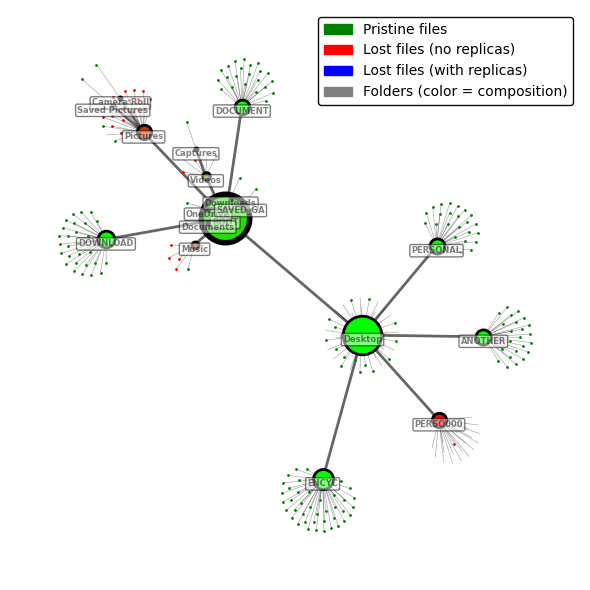

In [39]:
# pos = nx.kamada_kawai_layout(G)

# Create weighted graph
G_weighted = G.copy()
for u, v in G_weighted.edges():
    node_u_type = G_weighted.nodes[u].get('node_type')
    node_v_type = G_weighted.nodes[v].get('node_type')
    
    if (node_u_type == 'file' and node_v_type == 'folder') or \
       (node_u_type == 'folder' and node_v_type == 'file'):
        G_weighted[u][v]['weight'] = 0.5  # Weak attraction for files to folders
    else:
        G_weighted[u][v]['weight'] = 1.0  # Strong attraction between folders

pos = nx.spring_layout(
    G_weighted, 
    k=0.1,              # Lower k = nodes closer together (default is ~0.3)
    iterations=1500,      # More iterations = better convergence
    weight='weight',     # Use edge weights
    scale=0.8,           # Lower scale = more compact (default is 1.0)
    seed=42
)

# Uncomment for more compactness
# pos = {node: (x * scale_factor, y * scale_factor) for node, (x, y) in pos.items()}

fig, ax = plt.subplots(figsize=(6, 6), facecolor='white')

# Separate nodes by type
folder_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'folder']
file_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'file']

# Calculate total files for sizing
total_file_count = max(sum([G.nodes[n].get('total_files', 0) for n in folder_nodes]), 1)

# Draw edges
folder_edges = [(u, v) for u, v in G.edges() 
                if G.nodes[u].get('node_type') == 'folder' 
                and G.nodes[v].get('node_type') == 'folder']
file_edges = [(u, v) for u, v in G.edges() 
              if (G.nodes[u].get('node_type') == 'file') 
              or (G.nodes[v].get('node_type') == 'file')]

# Draw folder-folder edges (thicker)
nx.draw_networkx_edges(G, pos, edgelist=folder_edges, 
                      alpha=0.6, width=2.0, edge_color="#000000", ax=ax)

# Draw file-folder edges (thinner)
nx.draw_networkx_edges(G, pos, edgelist=file_edges, 
                      alpha=0.4, width=0.4, edge_color="#000000", ax=ax)

# Draw file nodes (colored by status)
pristine_files = [n for n in file_nodes if G.nodes[n].get('file_status') == 'pristine']
lost_files = [n for n in file_nodes if G.nodes[n].get('file_status') == 'lost']
replica_files = [n for n in file_nodes if G.nodes[n].get('file_status') == 'replica']

print( f"pristine_files: {pristine_files}" )
print( f"lost_files: {lost_files}" )
print( f"replica_files: {replica_files}" )

if pristine_files:
    nx.draw_networkx_nodes(G, pos, nodelist=pristine_files, 
                          node_color='green', node_size=1, alpha=1, ax=ax)
if lost_files:
    nx.draw_networkx_nodes(G, pos, nodelist=lost_files, 
                          node_color='red', node_size=1, alpha=1, ax=ax)
if replica_files:
    nx.draw_networkx_nodes(G, pos, nodelist=replica_files, 
                          node_color='blue', node_size=1, alpha=1, ax=ax)

# Draw folder nodes with color based on file composition
for folder_node in folder_nodes:
    pristine = G.nodes[folder_node].get('pristine_count', 0)
    lost = G.nodes[folder_node].get('lost_count', 0)
    replica = G.nodes[folder_node].get('replica_count', 0)
    total = pristine + lost + replica
    
    if total > 0:
        # Calculate color mixture (green for pristine, red for lost, blue for replicas)
        pristine_ratio = pristine / total
        lost_ratio = lost / total
        replica_ratio = replica / total
        
        r = lost_ratio
        g = pristine_ratio
        b = replica_ratio
        color = (r, g, b)
    else:
        color = (0.1, 0.1, 0.1)  # Lightgray for empty folders
    
    # Size based on file count
    file_count = G.nodes[folder_node].get('total_files', 0)
    
    # Special handling for root node
    if folder_node == root_path:
        size = (file_count / total_file_count) * 3000 #1200  # Larger root
        nx.draw_networkx_nodes(G, pos, nodelist=[folder_node],
                              node_color=[color], node_size=size, 
                              alpha=1, ax=ax, node_shape='o',
                              edgecolors='black', linewidths=4)
    else:
        size = (file_count / total_file_count) * 3000
        nx.draw_networkx_nodes(G, pos, nodelist=[folder_node],
                              node_color=[color], node_size=size, 
                              alpha=1, ax=ax, node_shape='o',
                              edgecolors='black', linewidths=2)

# Draw folder labels BELOW nodes in BLACK
folder_labels = {}
label_pos = {}

for folder_node in folder_nodes:
    if folder_node == root_path:
        folder_labels[folder_node] = 'ROOT'
    else:
        folder_name = folder_node.split('/')[-1]
        folder_labels[folder_node] = folder_name
    
    # label offset
    x, y = pos[folder_node]
    label_pos[folder_node] = (x, y)  # Adjust offset

bbox_props = dict(
    boxstyle="round,pad=0.2",   
    facecolor="white",          
    edgecolor="black",          
    alpha=0.5                   
)

nx.draw_networkx_labels(G, label_pos, folder_labels, font_size=6, 
                       font_weight='bold', font_color='black', alpha=0.5, 
                       verticalalignment='top', bbox=bbox_props, ax=ax)

# Legend
legend_elements = [
    mpatches.Patch(color='green', label='Pristine files'),
    mpatches.Patch(color='red', label='Lost files (no replicas)'),
    mpatches.Patch(color='blue', label='Lost files (with replicas)'),
    mpatches.Patch(color='gray', label='Folders (color = composition)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, 
         framealpha=0.95, edgecolor='black')

ax.axis('off')
plt.tight_layout()

# Save the figure
# plt.savefig('ransomware_kamada_kawai.png', dpi=150, bbox_inches='tight', facecolor='white')

plt.show()
